Step 1: Setting Up and Loading Data

In [68]:
"""
Breast Cancer Prediction with KNN
Author: Ben Mayer
Description: Predict whether a breast tumor is malignant or benign using KNN
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
 
# Load the breast cancer dataset
print("Loading breast cancer dataset...")
cancer_data = load_breast_cancer()
 
# The dataset is a Bunch object with 'data', 'target', 'feature_names', etc.
print(f"\nDataset type: {type(cancer_data)}")
print(f"Number of samples: {len(cancer_data.data)}")
print(f"Number of features: {len(cancer_data.feature_names)}")
print(f"Target classes: {cancer_data.target_names}")
 
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target
 
print("\nFirst few rows:")
print(df.head())
 
print("\nDataset info:")
print(df.info())
 
print("\nTarget distribution:")
print(df['target'].value_counts())
print(f"Malignant (1): {(df['target'] == 1).sum()}")
print(f"Benign (0): {(df['target'] == 0).sum()}")

Loading breast cancer dataset...

Dataset type: <class 'sklearn.utils._bunch.Bunch'>
Number of samples: 569
Number of features: 30
Target classes: ['malignant' 'benign']

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520

# Step 2: Data Exploration
Objective: Understand the data better through basic statistics and visualization.


BASIC STATISTICS
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.0

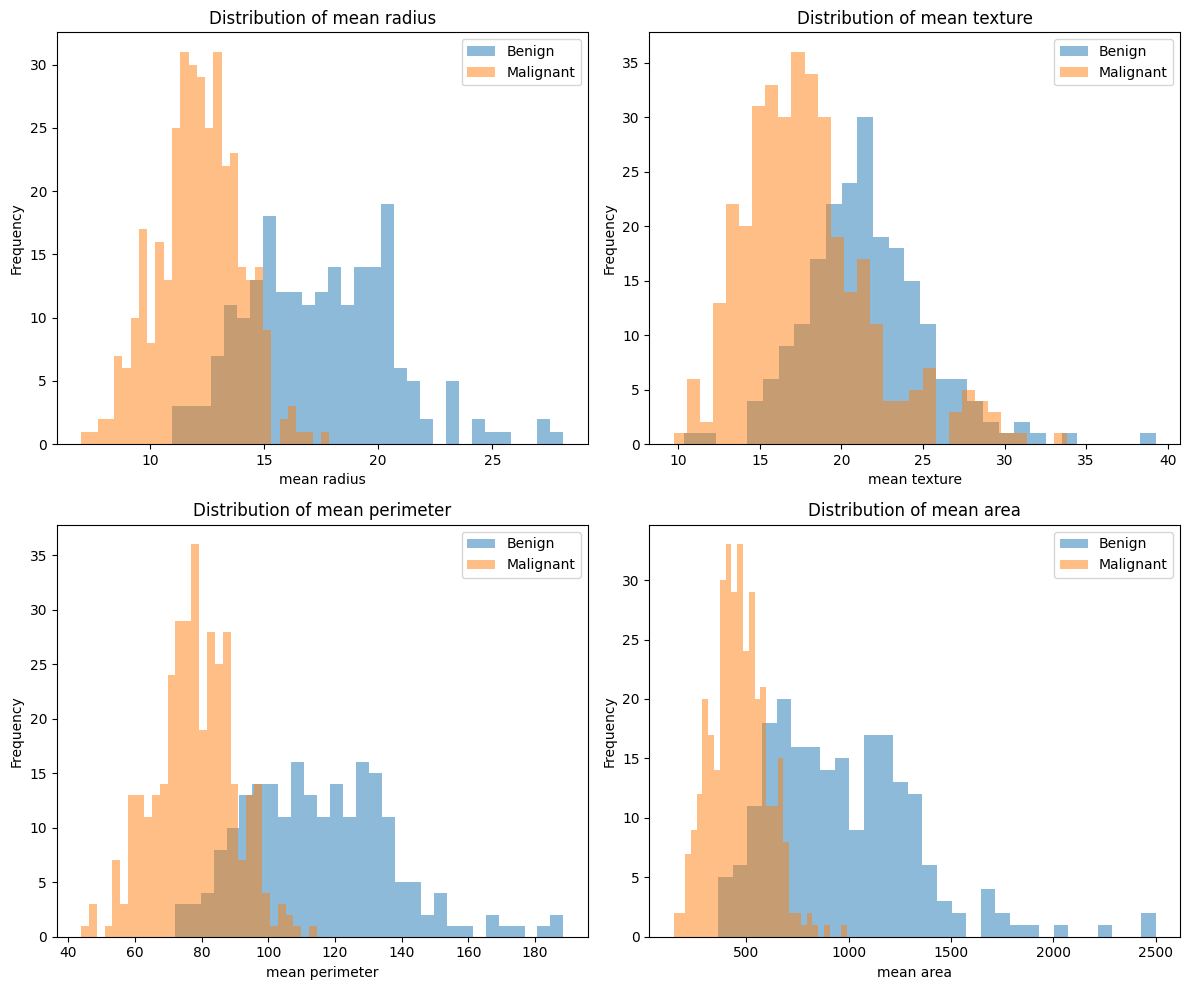

In [69]:
# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())
 
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])
 
# Visualize feature distributions (select a few key features)
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)
 
# Select a few representative features to visualize
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
 
for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['target'] == 0][feature], alpha=0.5, label='Benign', bins=30)
    axes[idx].hist(df[df['target'] == 1][feature], alpha=0.5, label='Malignant', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()
 
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions.png'")
plt.show()

# Step 3: Splitting the Data
Objective: Split the data into training and testing sets.

In [70]:
# Separate features and target
X = df.drop('target', axis=1)  # All columns except 'target'
y = df['target']  # Target column
 
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
 
# Split into training and testing sets
# random_state ensures reproducibility
# stratify=y ensures both sets have similar class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
 
print("\n" + "="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training features: {X_train.shape[1]}")
print(f"Test features: {X_test.shape[1]}")
 
# Verify class distribution in both sets
print("\nTraining set target distribution:")
print(y_train.value_counts())
print(f"  Benign (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
 
print("\nTest set target distribution:")
print(y_test.value_counts())
print(f"  Benign (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

Features shape: (569, 30)
Target shape: (569,)

DATA SPLIT
Training set size: 455 samples
Test set size: 114 samples
Training features: 30
Test features: 30

Training set target distribution:
target
1    285
0    170
Name: count, dtype: int64
  Benign (0): 170 (37.4%)
  Malignant (1): 285 (62.6%)

Test set target distribution:
target
1    72
0    42
Name: count, dtype: int64
  Benign (0): 42 (36.8%)
  Malignant (1): 72 (63.2%)


# Step 4: Training the KNN Model
Objective: Train a K-Nearest Neighbors classifier.

In [71]:
# Create KNN classifier
# n_neighbors=5 means the model will look at the 5 nearest neighbors to make a prediction
 
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)
 
print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")

KNN classifier trained successfully!
Number of neighbors (k): 2


# Step 5: Making Predictions
Objective: Use the trained model to make predictions on the test set.

In [72]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
 
print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")


Training predictions: 455
Test predictions: 114


Checking how they compare against actual values:

In [73]:
# Side-by-side comparison of actual vs predicted (test set)
comparison = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred,
})
comparison['correct'] = comparison['actual'] == comparison['predicted']

print(comparison.head(10))
print(f"\nCorrect: {comparison['correct'].sum()} / {len(comparison)}")

# Show only the mistakes
print("\nMisclassified samples:")
print(comparison[~comparison['correct']])

# Quick sanity checks
print("\nPredicted class counts:")
print(pd.Series(y_test_pred).value_counts())
print("\nActual class counts:")
print(y_test.value_counts())

# Train vs test accuracy (a big gap would su
print(f"\nTrain accuracy: {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Test accuracy:  {accuracy_score(y_test, y_test_pred):.3f}")

   actual  predicted  correct
0       0          0     True
1       1          1     True
2       0          0     True
3       1          0    False
4       0          0     True
5       1          1     True
6       1          1     True
7       0          0     True
8       0          0     True
9       0          0     True

Correct: 103 / 114

Misclassified samples:
     actual  predicted  correct
3         1          0    False
16        1          0    False
24        1          0    False
25        1          0    False
48        1          0    False
65        0          1    False
68        1          0    False
76        0          1    False
80        1          0    False
99        1          0    False
102       0          1    False

Predicted class counts:
1    67
0    47
Name: count, dtype: int64

Actual class counts:
target
1    72
0    42
Name: count, dtype: int64

Train accuracy: 0.967
Test accuracy:  0.904


# Step 6: Evaluating Model Performance
Objective: Calculate and interpret various evaluation metrics.

In [74]:
# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
 
print("=== Model Performance ===")
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
 
print("\n=== Confusion Matrix ===")
print("                Predicted")
print("              Benign  Malignant")
print(f"Actual Benign    {test_confusion[0,0]:4d}      {test_confusion[0,1]:4d}")
print(f"      Malignant  {test_confusion[1,0]:4d}      {test_confusion[1,1]:4d}")

# from sklearn.metrics import ConfusionMatrixDisplay

# ConfusionMatrixDisplay.from_predictions(
#     y_test, y_test_pred,
#     display_labels=cancer_data.target_names,
#     cmap='Blues',
# )
# plt.title("KNN Confusion Matrix (Test Set)")
# plt.show()
 
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=cancer_data.target_names))

=== Model Performance ===

Training Accuracy: 0.9670 (96.70%)
Test Accuracy: 0.9035 (90.35%)

Test Precision: 0.9552
Test Recall: 0.8889

=== Confusion Matrix ===
                Predicted
              Benign  Malignant
Actual Benign      39         3
      Malignant     8        64

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.83      0.93      0.88        42
      benign       0.96      0.89      0.92        72

    accuracy                           0.90       114
   macro avg       0.89      0.91      0.90       114
weighted avg       0.91      0.90      0.90       114



The above matrix visualisation was off, so here's an easier one to understand. 

In [75]:
 
print("=== Model Performance ===")
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")


# Confusion matrix as a readable table
# NOTE: sklearn encoding is 0 = malignant, 1 = benign (see cancer_data.target_names)
cm = confusion_matrix(y_test, y_test_pred)
mal, ben = cancer_data.target_names

rows = [
    [f"Actual {mal} ({cm[0].sum()})", f"{cm[0,0]}  correct",      f"{cm[0,1]}  MISSED CANCER"],
    [f"Actual {ben} ({cm[1].sum()})", f"{cm[1,0]}  false alarm",  f"{cm[1,1]}  correct"],
]
header = ["", f"Predicted {mal}", f"Predicted {ben}"]

w = [max(len(r[i]) for r in [header] + rows) + 2 for i in range(3)]
border = lambda l, m, r: l + m.join("─" * x for x in w) + r
fmt = lambda cells: "│" + "│".join(f" {c:<{x - 1}}" for c, x in zip(cells, w)) + "│"

print("\n=== Confusion Matrix (test set) ===")
print(border("┌", "┬", "┐"))
print(fmt(header))
print(border("├", "┼", "┤"))
print(fmt(rows[0]))
print(border("├", "┼", "┤"))
print(fmt(rows[1]))
print(border("└", "┴", "┘"))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=cancer_data.target_names))


=== Model Performance ===

Training Accuracy: 0.9670 (96.70%)
Test Accuracy: 0.9035 (90.35%)

Test Precision: 0.9552
Test Recall: 0.8889

=== Confusion Matrix (test set) ===
┌───────────────────────┬─────────────────────┬──────────────────┐
│                       │ Predicted malignant │ Predicted benign │
├───────────────────────┼─────────────────────┼──────────────────┤
│ Actual malignant (42) │ 39  correct         │ 3  MISSED CANCER │
├───────────────────────┼─────────────────────┼──────────────────┤
│ Actual benign (72)    │ 8  false alarm      │ 64  correct      │
└───────────────────────┴─────────────────────┴──────────────────┘

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.83      0.93      0.88        42
      benign       0.96      0.89      0.92        72

    accuracy                           0.90       114
   macro avg       0.89      0.91      0.90       114
weighted avg       0.91      0.90      0.90       114


# Step 7: Experimenting with Different K Values
Objective: Understand how the number of neighbors (K) affects model performance.


In [83]:
# Experiment with different K values
print("EXPERIMENTING WITH DIFFERENT K VALUES")
 
k_values = [1, 10, 100]
results = []
mal, ben = cancer_data.target_names  # sklearn encoding: 0 = malignant, 1 = benign
 
for k in k_values:
    # Create and train model
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    
    # Make predictions
    y_pred_temp = knn_temp.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec
    })
    
    print(f"\nK={k:2d}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")

    # Confusion matrix as a readable table (uses this K's predictions)
    # Helps me understand what the model is doing with different K values, what is the real world impact of Accuracy, Precision, Recall changes
    cm = confusion_matrix(y_test, y_pred_temp)

    rows = [
        [f"Actual {mal} ({cm[0].sum()})", f"{cm[0,0]}  correct",      f"{cm[0,1]}  MISSED CANCER"],
        [f"Actual {ben} ({cm[1].sum()})", f"{cm[1,0]}  false alarm",  f"{cm[1,1]}  correct"],
    ]
    header = ["", f"Predicted {mal}", f"Predicted {ben}"]

    w = [max(len(r[i]) for r in [header] + rows) + 2 for i in range(3)]
    border = lambda l, m, r: l + m.join("─" * x for x in w) + r
    fmt = lambda cells: "│" + "│".join(f" {c:<{x - 1}}" for c, x in zip(cells, w)) + "│"

    print(border("┌", "┬", "┐"))
    print(fmt(header))
    print(border("├", "┼", "┤"))
    print(fmt(rows[0]))
    print(border("├", "┼", "┤"))
    print(fmt(rows[1]))
    print(border("└", "┴", "┘"))


EXPERIMENTING WITH DIFFERENT K VALUES

K= 1: Accuracy=0.9211, Precision=0.9565, Recall=0.9167
┌───────────────────────┬─────────────────────┬──────────────────┐
│                       │ Predicted malignant │ Predicted benign │
├───────────────────────┼─────────────────────┼──────────────────┤
│ Actual malignant (42) │ 39  correct         │ 3  MISSED CANCER │
├───────────────────────┼─────────────────────┼──────────────────┤
│ Actual benign (72)    │ 6  false alarm      │ 66  correct      │
└───────────────────────┴─────────────────────┴──────────────────┘

K=10: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
┌───────────────────────┬─────────────────────┬──────────────────┐
│                       │ Predicted malignant │ Predicted benign │
├───────────────────────┼─────────────────────┼──────────────────┤
│ Actual malignant (42) │ 38  correct         │ 4  MISSED CANCER │
├───────────────────────┼─────────────────────┼──────────────────┤
│ Actual benign (72)    │ 4  false alarm      